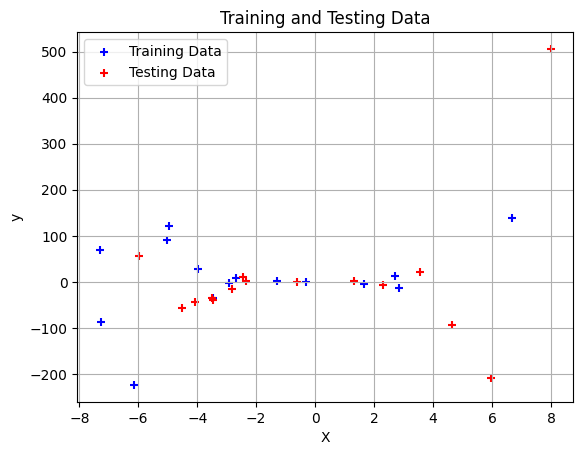

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#step 1.1

x_train= np.array([[-3.9852],[-7.2625],[2.8291],[-7.3045],[-6.1372],[1.6619],
                 [-4.9451],[2.6963],[6.6792],[-1.2995],[-2.6838],[-3.4715],
                 [-5.0195],[-2.9262],[-0.3013]]).reshape(-1,1)
y_train = np.array([
    [28.1908],
    [-86.2033],
    [-13.6625],
    [ 68.7593],
    [-223.631],
    [ -4.6456],
    [ 120.8628],
    [ 13.4804],
    [138.9255],
    [1.7485],
    [8.8414],
    [-35.1241],
    [90.9571],
    [-1.8887],
    [-0.0193]
]).reshape(-1,1)

x_test = np.array([[-5.9804],[-2.8337],[2.2868],[7.9915],[-3.504],[1.3156],
                 [5.9616],[4.6294],[-4.5106],[-2.454],[3.544],[-2.3373],
                 [-0.6291],[-4.0896],[-3.4774]]).reshape(-1,1)
y_test = np.array([
    [55.9095],
    [ -15.6288],
    [ -6.7248],
    [ 505.6809],
    [ -35.912],
    [ 2.5732],
    [ -208.5399],
    [ -94.5373],
    [ -55.7882],
    [10.9505],
    [21.6595],
    [2.9701],
    [-0.7869],
    [-44.7166],
    [-38.9733]
]).reshape(-1,1)

# Plotting Training Data (X, y)
plt.figure()
plt.scatter(x_train, y_train, color='blue', marker='+', label='Training Data')

# Plotting Testing Data (X_test, y_test)
plt.scatter(x_test, y_test, color='red', marker='+', label='Testing Data')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Training and Testing Data')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
#step 1.2
def sine_poly_features(X, K):
    # return np.hstack([X**i for i in range(K + 1)])
    X= X.flatten()
    N= X.shape[0]
    Phi= np.zeros((N,K+1))
    for k in range (K+1):
        Phi[:,k]= np.sin(X**k)
    return Phi

Theta_ml:
 [[  7.23389189]
 [ -7.13269171]
 [-64.78924738]
 [-98.23949558]
 [-22.31129602]
 [-74.79029812]]
Theta_ml_test:
 [[ 2.18563059]
 [49.23151416]
 [44.67854649]
 [40.41626919]
 [-0.67834693]
 [15.1874561 ]]


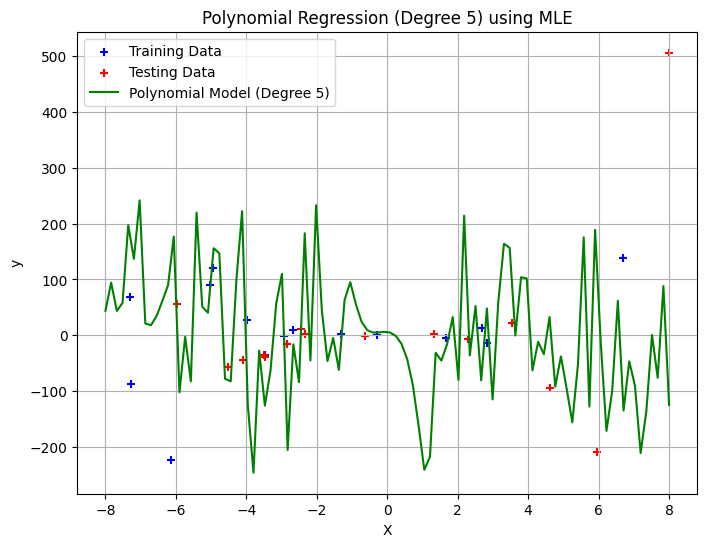

In [9]:
#step 1.3
# Polynomial degree
K = 5

# Transform both training and testing data
Phi_train = sine_poly_features(x_train, K)
Phi_test = sine_poly_features(x_test, K)

def nonlinear_features_maximum_likelihood(Phi_train, y_train):
    theta_ml = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train
    return theta_ml
theta_ml = nonlinear_features_maximum_likelihood(Phi_train, y_train)
print("Theta_ml:\n", theta_ml)

# Compute MLE coefficients: theta_MLE = (Phi^T Phi)^(-1) Phi^T y
def nonlinear_features_maximum_likelihood(Phi_test, y_test):
    theta_ml_test = np.linalg.inv(Phi_test.T @ Phi_test) @ Phi_test.T @ y_test
    return theta_ml_test
theta_ml_test = nonlinear_features_maximum_likelihood(Phi_test, y_test)
print("Theta_ml_test:\n", theta_ml_test)

# Generate a range of x values from -8 to 8 for plotting the model's predictions
X_plot = np.linspace(-8, 8, 100).reshape(-1,1)
Phi_plot = sine_poly_features(X_plot, K)
y_plot = Phi_plot @ theta_ml

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(x_train, y_train, color='blue',marker='+' ,label='Training Data')
plt.scatter(x_test, y_test, color='red',marker='+',label='Testing Data')

# Plot the polynomial fit
plt.plot(X_plot, y_plot, color='green', label='Polynomial Model (Degree 5)')

plt.title('Polynomial Regression (Degree 5) using MLE')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()



Train RMSE values: [84.10181047943314, 80.84568854021033, 80.74296281893345, 72.19319353800687, 72.18957216422945, 61.85730683564019, 59.17245630971444, 59.1627271465335, 58.43824092521036, 57.60901663514197, 50.818262613123636, 50.13353754420509, 48.85497468886858, 39.33753601204929, 5.8907743250876064e-12, 44.646258083367215]
Test RMSE values: [145.9321846163667, 139.07618277722233, 136.8104076114915, 161.55871069193367, 161.07805911915804, 212.07307819562322, 197.33894683689263, 197.10684936036066, 192.965401187342, 216.2676937885293, 226.74981515869936, 197.59353571128952, 177.0759939567367, 173.4694739251339, 2003.4956231901965, 634.5217591797257]
Optimal polynomial degree (based on test RMSE): 2


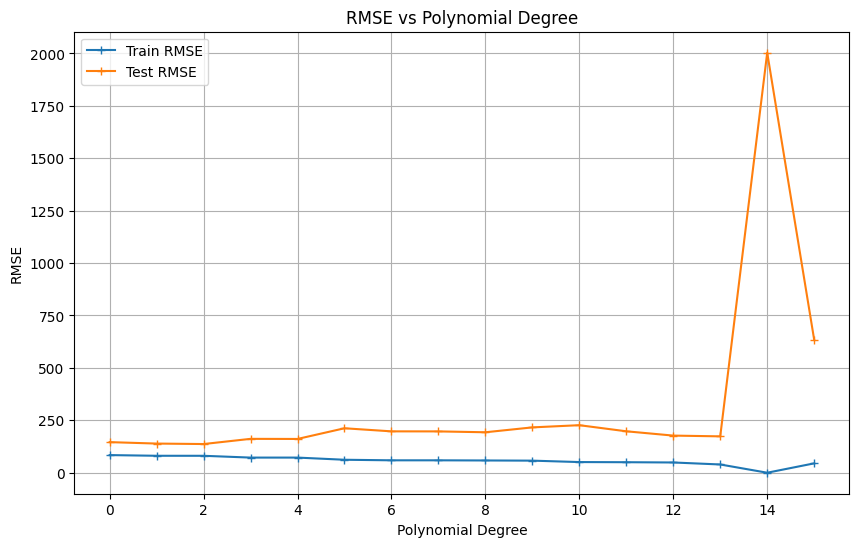

In [4]:
#step 1.4
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

max_degree = 16
train_rmse_values = []
test_rmse_values = []

for d in range(max_degree):
    # Generate polynomial features for both training and testing sets
    Phi_train = sine_poly_features(x_train, d)
    Phi_test = sine_poly_features(x_test, d)

    # Compute theta_MLE = (Phi^T Phi)^(-1) Phi^T y
    # Handle the case d=0 where Phi is just a column of ones
    theta_ml = np.linalg.inv(Phi_train.T @ Phi_train) @ (Phi_train.T @ y_train)

    # Predictions
    y_pred_train = Phi_train @ theta_ml
    y_pred_test = Phi_test @ theta_ml

    # Compute RMSE for train and test
    train_rmse = rmse(y_train, y_pred_train)
    test_rmse = rmse(y_test, y_pred_test)

    train_rmse_values.append(train_rmse)
    test_rmse_values.append(test_rmse)

# Determine optimal polynomial degree based on minimum test RMSE
optimal_degree = np.argmin(test_rmse_values)

print("Train RMSE values:", train_rmse_values)
print("Test RMSE values:", test_rmse_values)
print(f"Optimal polynomial degree (based on test RMSE): {optimal_degree}")

# Plotting the RMSE for training and testing sets
plt.figure(figsize=(10,6))
plt.plot(range(max_degree), train_rmse_values, marker='+', label='Train RMSE')
plt.plot(range(max_degree), test_rmse_values, marker='+', label='Test RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs Polynomial Degree')
plt.grid(True)
plt.legend()
plt.show()

Optimal polynomial degree (based on test RMSE): 2


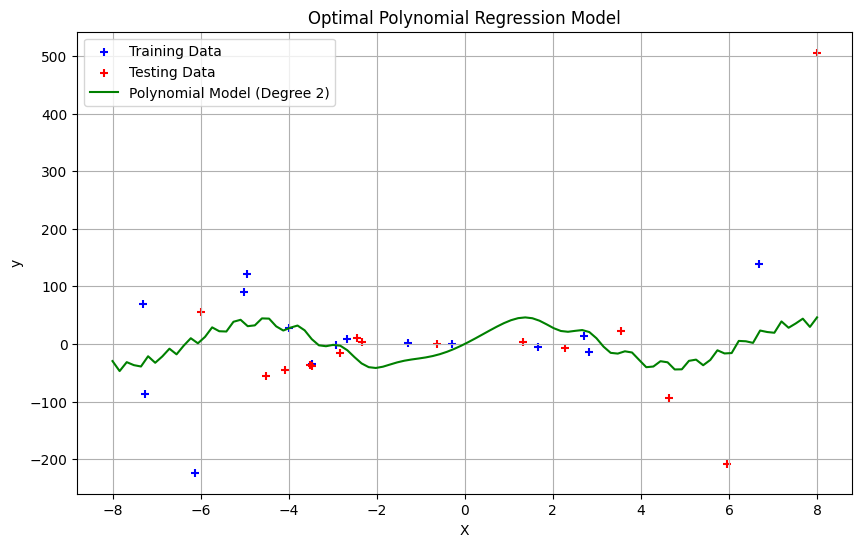

In [5]:
#step 1.5
# Re-fit the model using the optimal degree
Phi_train_opt = sine_poly_features(x_train, optimal_degree)
theta_MLE_opt = np.linalg.inv(Phi_train_opt.T @ Phi_train_opt) @ (Phi_train_opt.T @ y_train)

# Generate predictions over the range [-8, 8]
x_test_all = np.linspace(-8, 8, 100).reshape(-1,1)
Phi_plot = sine_poly_features(x_test_all, optimal_degree)
y_plot = Phi_plot @ theta_MLE_opt
print(f"Optimal polynomial degree (based on test RMSE): {optimal_degree}")
# Plot the results
plt.figure(figsize=(10,6))
plt.scatter(x_train, y_train, color='blue',marker='+', label='Training Data')
plt.scatter(x_test, y_test, color='red',marker='+', label='Testing Data')
plt.plot(x_test_all, y_plot, color='green', label=f'Polynomial Model (Degree {optimal_degree})')

plt.title('Optimal Polynomial Regression Model')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()